In [1]:
import pandas as pd
import numpy as np
import os
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"]="platform"


from pathlib import Path
import pickle
import time
from itertools import product

#### graphical
import matplotlib.pyplot as plt
import corner


import numpyro, os, json
import numpyro.distributions as dist
import jax.numpy as jnp
from numpyro.infer import Predictive
import arviz as az
import jax

from numpyro import handlers
from numpyro.infer import MCMC, NUTS, Predictive

from emulator import Emulator
from utils import norm, unnorm 

from numpyro.handlers import reparam
from numpyro.infer.reparam import LocScaleReparam

from jax import vmap, Array

import tensorflow as tf
os.environ["CUDA_VISIBLE_DEVICES"]="1"
jax.config.update('jax_enable_x64', True)
numpyro.enable_x64()

2025-02-28 16:56:48.812234: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1740761808.824010 1789801 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1740761808.827741 1789801 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
def sample_beta(param_name, loc, scale, alpha = 2, beta = 2):

    beta_samp = numpyro.sample(f'{param_name}_beta', dist.Beta(alpha, beta))

    return numpyro.deterministic(param_name, loc + scale*beta_samp)

In [3]:
from jax.lib import xla_bridge
print(xla_bridge.get_backend().platform)

gpu


/tmp/ipykernel_1789801/1991717721.py:2: DeprecationWarning: jax.lib.xla_bridge.get_backend is deprecated; use jax.extend.backend.get_backend.
  print(xla_bridge.get_backend().platform)


In [4]:
normconsts = np.load('../grids/Chiara-normconsts.npy', allow_pickle = True).item()

modelpath = '/home/hatte/M4/models'

n_dense_layers = 2

dense_layer_units = 512

Nepochs = 200000

learning_rate = 0.001

model_name = 'logLPhot'

loss_func = 'MSE'

checkpoint_dir = f'{modelpath}/long-runs/checkpoint/chk-{model_name}-nlayers-{n_dense_layers}-nunits-{dense_layer_units}-epochs-{Nepochs}-lrate-{learning_rate}-lossfunc-{loss_func}.model.keras'

emulator_kwargs =  {'model_name':'logLPhot', 'n_dense_layers':2, 'dense_layer_units':512, 'Nepochs':200000, 'lrate':0.001, \
        'loss':'MSE', 'model_dir':'../models',  'inputs': ['massini', 'zini', 'yini', 'alphaMLT', 'age', 'eta', 'alphaFe'], 'outputs':['FeH', 'logLPhot', 'Teff', 'numax', 'dnuSer'],\
        'normconsts':normconsts, 'checkpoint_dir':checkpoint_dir}

model_outputs = Emulator(emulator_kwargs, normalised = False)


I0000 00:00:1740761810.111688 1789801 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 18441 MB memory:  -> device: 0, name: NVIDIA RTX A4500, pci bus id: 0000:61:00.0, compute capability: 8.6


In [5]:
df_full = pd.read_hdf('../grids/Chiara.hdf5', key='df')

df_full['logLPhot'] = np.log10(df_full['LPhot'])

inputs = model_outputs.inputs

outputs = ['FeH', 'LPhot', 'Teff', 'numax', 'dnuSer']

hierarchical_params = ['mu_age', 'std_age']

df = df_full[inputs+outputs+['logLPhot']]

normconsts['LPhot'] = (np.min(df_full['LPhot']), np.max(df_full['LPhot']))

seed = 42

#Then I pick a hare - I need to try with an emu instead, this was just quick to make sure the sampling runs at al
input_consts = np.load('./fake-data/fake-cluster-observations-from-one-hare-consts.npy', allow_pickle = True).item()

obs = pd.read_csv('./fake-data/fake-cluster-observations-from-one-hare.csv')

df_small = df.sample(frac = 0.001, random_state = seed)

num_stars = len(obs['FeH'])
obs

,massini,zini,yini,alphaMLT,age,eta,alphaFe,FeH,LPhot,Teff,numax,dnuSer,logLPhot
0,0.807656,0.001805,0.269842,1.946531,12729.662149,0.049609,0.200112,-0.996643,NaN,5012.446565,0.011045,0.033145,1.662175
1,0.832819,0.001806,0.268069,1.993432,11539.283797,0.049584,0.194868,-0.993453,NaN,5029.994295,0.010829,0.032668,1.694773
2,0.779324,0.001805,0.272939,2.009218,14270.651292,0.053721,0.173539,-0.978780,NaN,5077.656526,0.011521,0.036160,1.591529
3,0.825937,0.001805,0.268647,1.997106,11849.777391,0.042696,0.204215,-0.999313,NaN,5035.972648,0.010304,0.031878,1.682327
4,0.811408,0.001805,0.269621,1.890220,12542.238726,0.046037,0.214508,-1.006042,NaN,4986.959600,0.011975,0.034821,1.637176
5,0.845797,0.001806,0.266825,1.939477,10982.183284,0.041711,0.195187,-0.992417,NaN,4994.630833,0.010396,0.031412,1.704814
6,0.834077,0.001805,0.267943,2.021563,11483.683156,0.055731,0.199900,-0.997029,NaN,5041.867156,0.010555,0.032135,1.705388
7,0.789040,0.001806,0.271761,1.908840,13715.875745,0.028827,0.204915,-1.002114,NaN,5007.852007,0.013369,0.038005,1.603845
8,0.807541,0.001805,0.269973,1.954365,12735.429239,0.068834,0.201139,-0.997712,NaN,4971.281586,0.008900,0.027977,1.749090
9,0.824998,0.001805,0.268803,1.983784,11892.993064,0.046662,0.195614,-0.992711,NaN,5009.096937,0.009299,0.029450,1.718723


In [6]:
prior_values = [input_consts['massini'][0], input_consts['zini'][0], input_consts['yini'][0], input_consts['alphaMLT'][0], \
                input_consts['age'][0], input_consts['eta'][0], input_consts['alphaFe'][0]]

prior_widths = [0.1, 1.5, 0.1, 0.1, 3000, 0.1, 0.03] 

priors = [(prior_values[i], prior_widths[i]) for i in range(len(prior_values))]

cluster_consts = {}

for key, value in zip(model_outputs.inputs, priors):
    if key not in cluster_consts:
        cluster_consts[key] = value
    else:
        cluster_consts[key].append(value)


In [7]:
fake_obs = {'FeH':obs['FeH'].values,  'Teff':obs['Teff'].values, 'numax':3090*obs['numax'].values, 'dnuSer':135*obs['dnuSer'].values, 'logLPhot':obs['logLPhot'].values}
fake_obs

{'FeH': array([-0.9966434 , -0.99345284, -0.97877964, -0.99931266, -1.00604161,
        -0.99241675, -0.99702918, -1.00211413, -0.99771225, -0.99271075,
        -0.99662523, -0.99888228, -1.00269551, -0.98428659, -0.99245983,
        -0.99113197, -0.99682045, -0.98803135, -0.99456207, -0.99803394,
        -1.00238247, -0.99468496, -1.00400533, -0.99205976, -0.98938809,
        -0.98984753, -0.98985218, -0.99808418, -0.97897781, -1.0012537 ]),
 'Teff': array([5012.44656479, 5029.99429544, 5077.65652615, 5035.97264837,
        4986.95959967, 4994.63083279, 5041.86715616, 5007.8520069 ,
        4971.28158638, 5009.09693683, 4918.41645981, 5138.99739512,
        5032.54287734, 4972.68148535, 5026.65795642, 5003.04786741,
        4985.7491013 , 5067.43239667, 5045.42124645, 5078.85438918,
        4958.55557205, 5082.56690628, 5007.79693743, 4955.89126192,
        5054.57045734, 5118.89767757, 5005.17566304, 4946.95066181,
        5065.45036194, 5089.54094207]),
 'numax': array([34.12926066,

# Make a fake cluster

In [8]:
def shared_age(uncs, consts = cluster_consts, obs = model_outputs.obs_dict):

    mu_age = sample_beta('mu_age', consts['age'][0] - consts['age'][1], 2*consts['age'][1], alpha = 2, beta = 2)

    std_age = sample_beta('std_age', consts['age'][1] - 0.3*consts['age'][1], 0.6*consts['age'][1], alpha = 10, beta = 10)

    with numpyro.plate("star", num_stars):

        age = numpyro.sample('age', dist.Normal(mu_age, std_age))

        tau = sample_beta('tau', 1, 0.1, alpha = 10, beta = 10)

        massini = numpyro.deterministic ('massini', (0.6426*10**4/age)**(1/3.2))

        zini = numpyro.sample('zini', dist.LogNormal(np.log(consts['zini'][0]), 1))

        yini = numpyro.sample('yini', dist.LogNormal(np.log(consts['yini'][0]), consts['yini'][1]))

        alphaMLT = numpyro.sample('alphaMLT', dist.TruncatedNormal(consts['alphaMLT'][0],consts['alphaMLT'][1], low = 1.5, high = 2.3))

        eta = numpyro.sample('eta', dist.TruncatedNormal(consts['eta'][0], consts['eta'][1], low = 0, high = 0.3))

        alphaFe = numpyro.sample('alphaFe', dist.Normal(consts['alphaFe'][0], consts['alphaFe'][1]))
               
        params = jnp.stack([massini, zini, yini, alphaMLT, age, eta, alphaFe], axis = -1)

        pred = model_outputs(params)



    FeH = numpyro.sample("FeH", dist.Normal(pred[:, 0], uncs['FeH']), obs=obs['FeH'])
    
    logLPhot = numpyro.sample("logLPhot", dist.LogNormal(jnp.log(pred[:, 1]), uncs['logLPhot']), obs=obs['logLPhot'])

    Teff = numpyro.sample("Teff", dist.Normal(pred[:, 2], uncs['Teff']), obs=obs['Teff'])

    numax = numpyro.sample("numax", dist.Normal(pred[:, 3]*3090, uncs['numax']), obs=obs['numax'])

    dnu = numpyro.sample("dnuSer", dist.Normal(pred[:, 4]*135, uncs['dnuSer']), obs=obs['dnuSer'])
 





In [9]:
phys_unc = {'Teff':150, 'numax': 0.1*fake_obs['numax'], 'dnuSer':0.1*fake_obs['dnuSer'], 'FeH':0.1, 'logLPhot':0.05}
#Large errors on numax and dnu reflective of std on residuals from the network

In [10]:
num_warmup, num_samples = 4000, 5000

num_chains = 1

sampler = NUTS(shared_age, target_accept_prob=0.8, find_heuristic_step_size=True, init_strategy=numpyro.infer.init_to_median) #May be worth trying init_to_sample

mcmc = MCMC(sampler, num_warmup=num_warmup, num_samples=num_samples, num_chains=num_chains)

In [11]:
rng_key = jax.random.PRNGKey(0)

rng_key, rng_key_ = jax.random.split(rng_key)

num_prior_samples = 1000

prior_predictive = Predictive(shared_age, num_samples=num_prior_samples,)

prior = prior_predictive(rng_key_, \
                         uncs=phys_unc, )

coords = {"star": np.arange(num_stars)}
dims = {}
for key, value in prior.items():
    dims[key] = dim = []
    if value.ndim == 1:
        continue
    if value.shape[-1] == num_stars:
        dim.append("star")

data = az.from_numpyro(prior=prior, coords=coords, dims=dims)
data

Inference data with groups:
	> prior

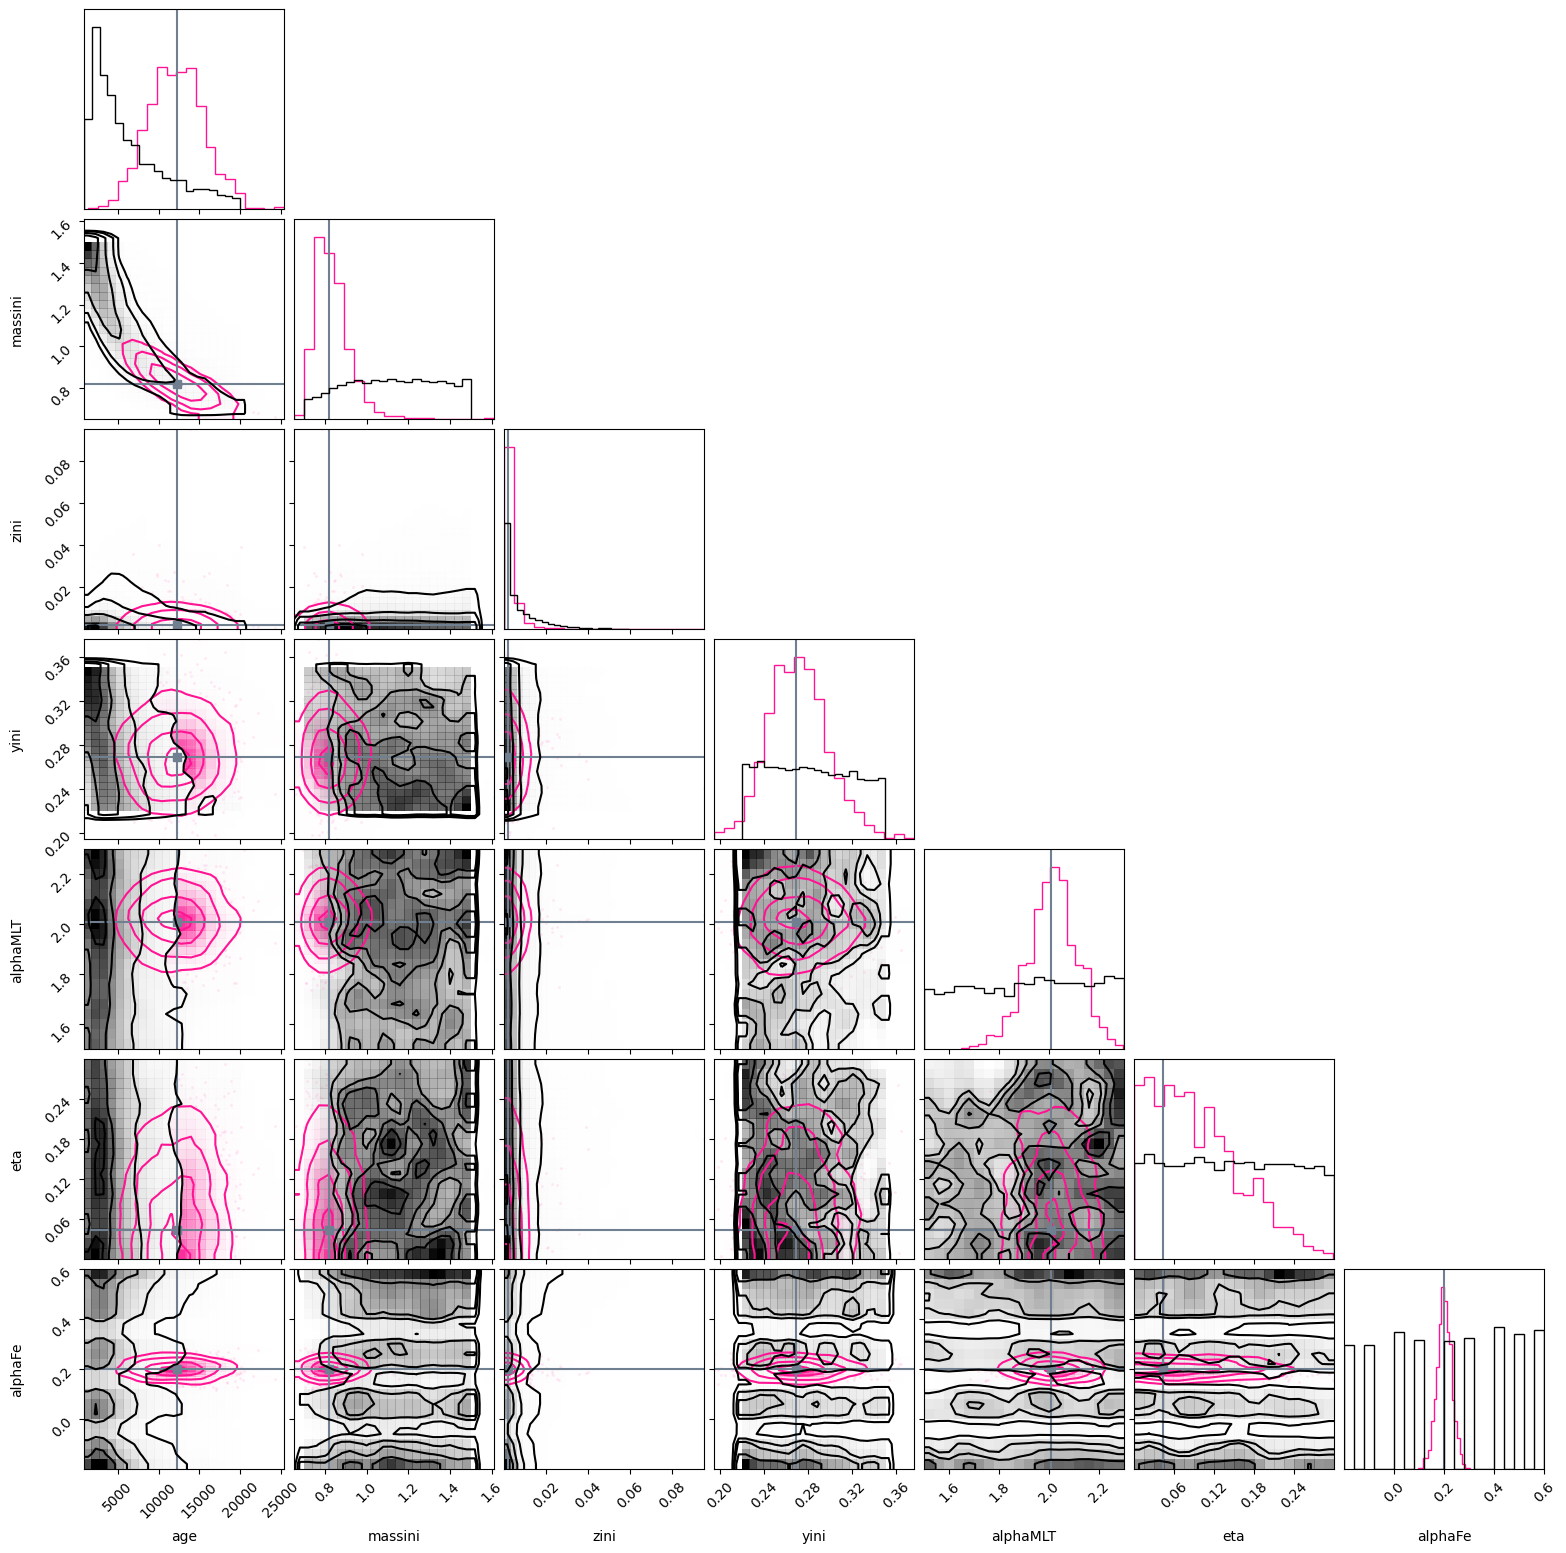

In [69]:
fig = corner.corner(data, group="prior", var_names = ['age', 'massini', 'zini', 'yini', 'alphaMLT', 'eta', 'alphaFe'],  color = 'deeppink', smooth = True, plot_datapoints = True, truths = [cluster_consts[i][0] for i in ['age', 'massini', 'zini', 'yini', 'alphaMLT', 'eta', 'alphaFe']], truth_color = 'slategrey', weights = np.ones(num_prior_samples)/(num_prior_samples), zorder = 100, coords = {'star':0})
corner.corner(df_small[['age', 'massini', 'zini', 'yini', 'alphaMLT', 'eta', 'alphaFe']],zorder = 0, alpha = 0.1, fig = fig, smooth = True, weights = np.ones_like(df_small['massini'])/len(df_small), plot_datapoints = False,)
plt.show()

In [70]:
mcmc.run(jax.random.PRNGKey(0),  uncs=phys_unc, obs=fake_obs)

mcmc.print_summary()

sample: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9000/9000 [2:01:45<00:00,  1.23it/s, 1023 steps of size 6.32e-04. acc. prob=0.93]


                    mean       std    median      5.0%     95.0%     n_eff     r_hat
        age[0]  12902.33   1543.91  13241.06  10035.35  14870.68      7.58      1.20
        age[1]  10311.08   2082.46  10840.25   6971.66  13086.84      9.72      1.03
        age[2]  13224.77   2047.58  13088.09  10771.22  17654.99     13.94      1.16
        age[3]  11249.71   3097.39  11207.35   6711.26  16787.98     17.99      1.08
        age[4]  12834.17   1187.37  12875.21  10699.55  14334.39      7.34      1.04
        age[5]  11492.53   2800.29  11410.44   7091.07  16354.93     39.61      1.04
        age[6]   9537.91   2187.13   9428.55   6221.01  13039.43     21.72      1.01
        age[7]  10797.08   2831.59  10468.51   6601.32  15773.09     44.13      1.02
        age[8]  10942.96   2736.31  10832.24   6515.04  15217.74     20.10      1.01
        age[9]  10995.91   2139.98  10902.34   6964.49  14464.21     11.44      1.07
       age[10]  10855.36     21.28  10855.15  10821.20  10890.59

In [71]:
posterior = mcmc.get_samples(group_by_chain=True)

sample_stats = mcmc.get_extra_fields(group_by_chain=True)

rng, key = jax.random.split(jax.random.PRNGKey(0))

posterior_predictive = Predictive(shared_age, posterior_samples=posterior, parallel=True, batch_ndims=2)

sample_stats = mcmc.get_extra_fields(group_by_chain=True)

data += az.from_dict(posterior, sample_stats=sample_stats, coords=coords, dims=dims)

In [16]:
data += az.from_dict(posterior, coords=coords, dims=dims)

In [74]:
np.save('./fake-data/posterior-30-stars-hier-age.npy', posterior, allow_pickle = True)

In [12]:
posterior = np.load('./fake-data/posterior-30-stars-hier-age.npy', allow_pickle = True).item()

In [13]:
params = jnp.stack([posterior['massini'][0].T, posterior['zini'][0].T, posterior['yini'][0].T, posterior['alphaMLT'][0].T, posterior['age'][0].T, posterior['eta'][0].T, posterior['alphaFe'][0].T], axis = -1)

pred = model_outputs(params)


E0228 16:56:19.278712 1789101 pjrt_stream_executor_client.cc:3026] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Failed to allocate request for 585.94MiB (614400000B) on device ordinal 0


ValueError: RESOURCE_EXHAUSTED: Failed to allocate request for 585.94MiB (614400000B) on device ordinal 0

In [ ]:

fig = corner.corner(data, group="prior", var_names = ['age', 'massini', 'zini', 'yini', 'alphaMLT', 'eta', 'alphaFe'],  color = 'lightskyblue', smooth = True, plot_datapoints = True, truths = [cluster_consts[i][0] for i in ['age', 'massini', 'zini', 'yini', 'alphaMLT', 'eta', 'alphaFe']], truth_color = 'slategrey', weights = np.ones(num_prior_samples)/(num_prior_samples), coords = {'star':0})
corner.corner(data, group="posterior", var_names = ['age', 'massini', 'zini', 'yini', 'alphaMLT', 'eta', 'alphaFe'],  color = 'deeppink', zorder = 1,smooth = True, plot_datapoints = True, truths = [cluster_consts[i][0] for i in ['age', 'massini', 'zini', 'yini', 'alphaMLT', 'eta', 'alphaFe']], truth_color = 'slategrey', weights = np.ones(num_chains*num_samples)/(num_chains*num_samples),fig = fig, coords = {'star':0})
#fig.savefig(f'./corner-hare-idx-{hare_idx}-massfromage-zini-{prior_widths[1]}-yini-{prior_widths[2]}-alphaMLT-{prior_widths[3]}-age-{prior_widths[4]}-eta-{prior_widths[5]}-alphaFe-{prior_widths[6]}.png', bbox_inches = 'tight', dpi = 150)
plt.show()


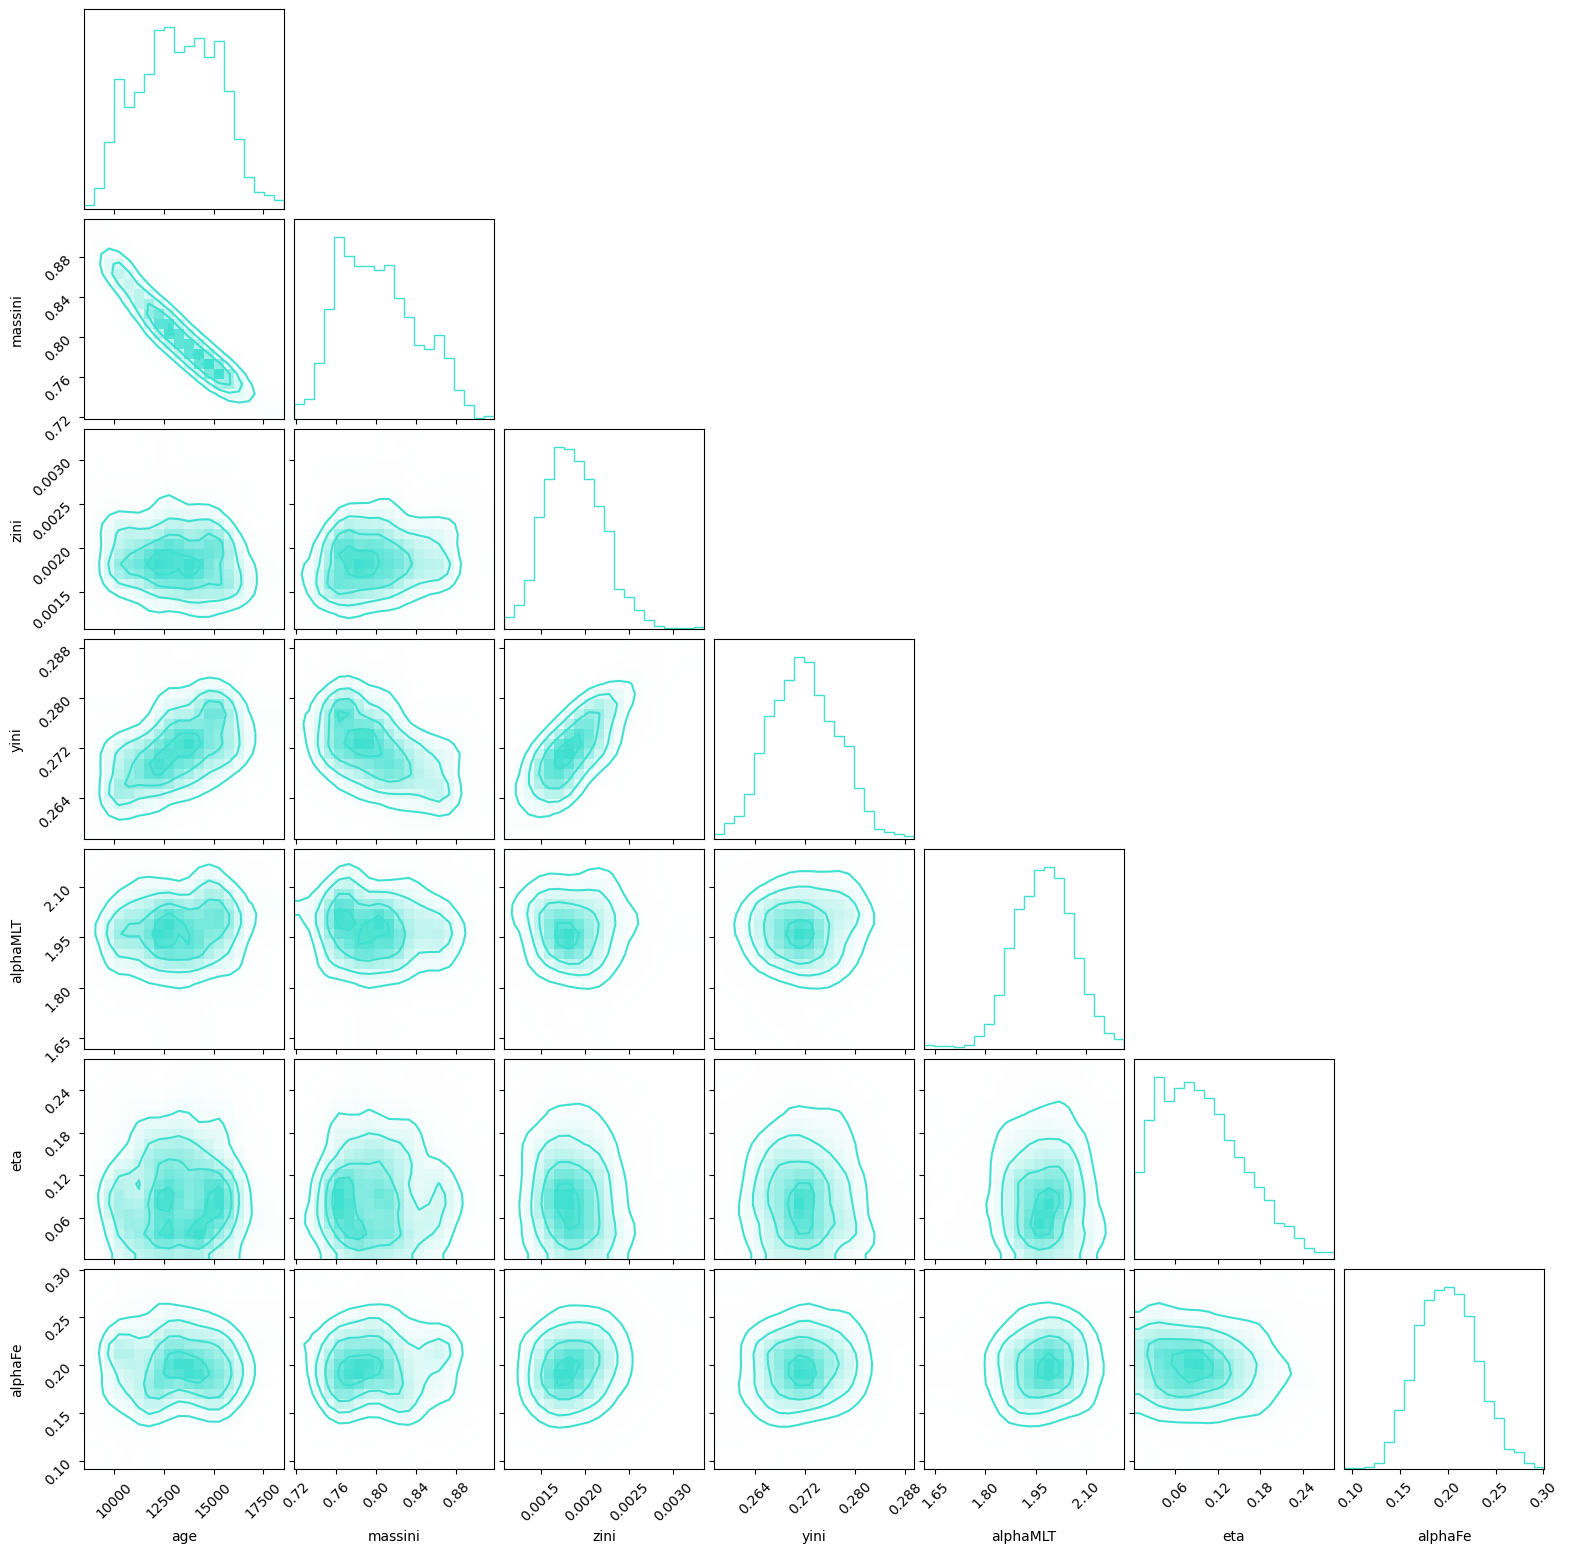

In [25]:
fig = corner.corner(data, group="posterior", var_names = ['age', 'massini', 'zini', 'yini', 'alphaMLT', 'eta', 'alphaFe'], coords = {'star':20}, plot_datapoints = False, smooth = True, color = 'turquoise')
fig.savefig(f'./corner-hierarchical-on-age-massfromage-zini-{prior_widths[1]}-yini-{prior_widths[2]}-alphaMLT-{prior_widths[3]}-age-{prior_widths[4]}-eta-{prior_widths[5]}-alphaFe-{prior_widths[6]}.png', bbox_inches = 'tight', dpi = 150)
plt.show()

In [45]:
cluster_df = pd.DataFrame(columns = model_outputs.outputs)

cluster_df['FeH'] = pred[0].T[0]

cluster_df['logLPhot'] = pred[0].T[1]

cluster_df['Teff'] = pred[0].T[2]

cluster_df['numax'] = pred[0].T[3]*3090

cluster_df['dnuSer'] = pred[0].T[4]*135

draws = cluster_df.sample(1000)



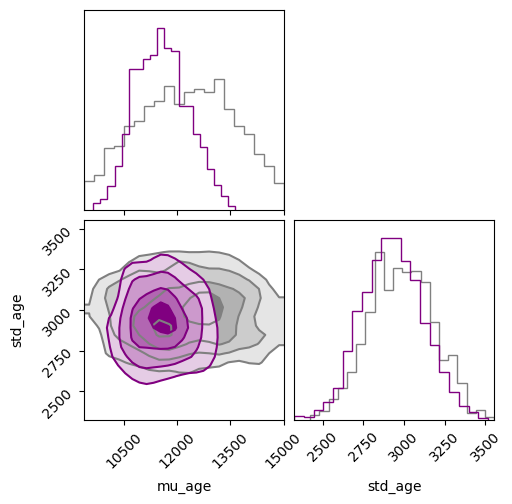

In [42]:
fig = corner.corner(data, group = 'prior', var_names = hierarchical_params, color = 'grey', smooth = True, weights = np.ones(num_prior_samples)/num_prior_samples, alpha = 0.02, fill_contours = True, plot_datapoints = False)
corner.corner(data, group="posterior", var_names = hierarchical_params, color = 'purple', plot_datapoints = False, smooth = True, fig = fig, weights = np.ones(num_chains*num_samples)/(num_chains*num_samples), fill_contours = True)
fig.savefig(f'corner-hierarchical-on-age-hparams-massfromage-zini-{prior_widths[1]}-yini-{prior_widths[2]}-alphaMLT-{prior_widths[3]}-age-{prior_widths[4]}-eta-{prior_widths[5]}-alphaFe-{prior_widths[6]}.png', bbox_inches = 'tight', dpi = 150, )
plt.show()

Text(0, 0.5, 'log(L/L$_{\\odot}$)')

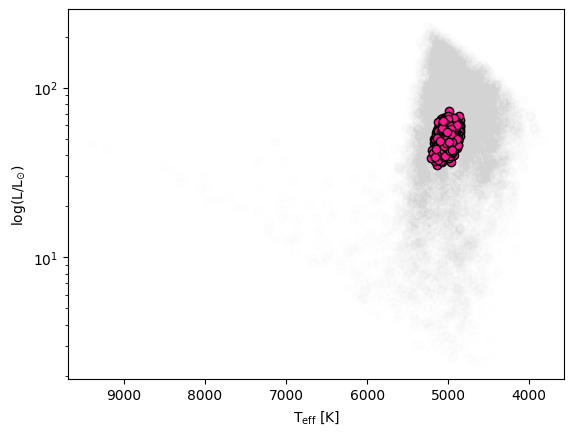

In [48]:
plt.scatter(df_small['Teff'], 10**df_small['logLPhot'], color = 'lightgrey', alpha = 0.01)
plt.scatter(draws['Teff'], 10**draws['logLPhot'], facecolor = 'deeppink', edgecolor = 'black')
plt.gca().invert_xaxis()
plt.semilogy()
plt.xlabel(r'T$_{\mathrm{eff}}$ [K]')
plt.ylabel(r'log(L/L$_{\odot}$)')


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

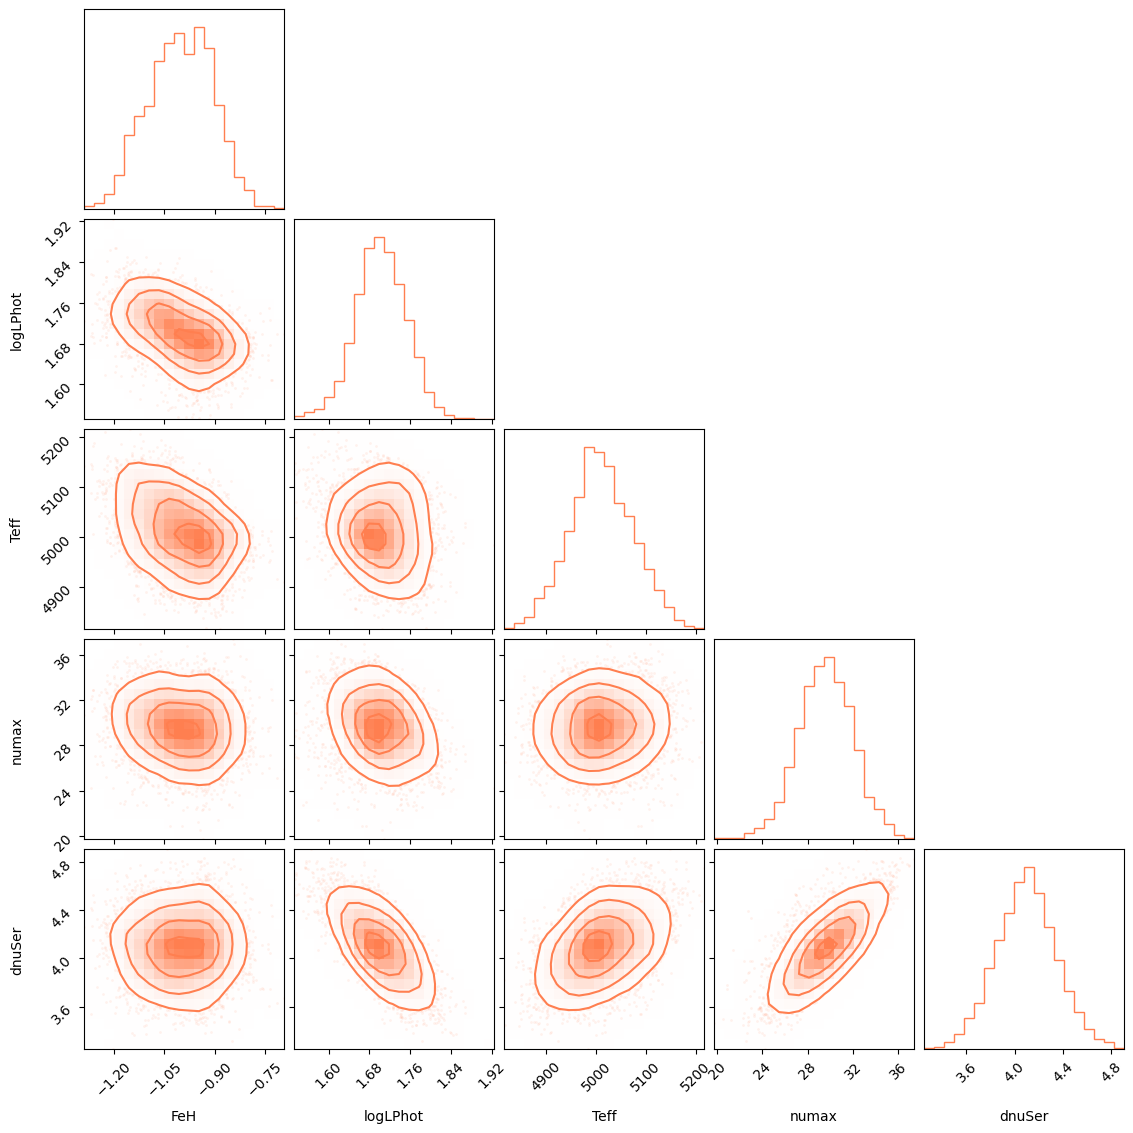

In [49]:
fig = corner.corner(cluster_df[model_outputs.outputs], smooth = True, color = 'coral', truths = [fake_obs[i] for i in model_outputs.outputs], truth_color = 'slategrey')
plt.show()

In [50]:
fake_obs

{'FeH': array([-0.9906374 , -0.99513751, -0.99029538, -0.99978379, -1.0015484 ,
        -1.00033814, -0.98647028, -0.99019231, -1.00426816, -1.01098226,
        -0.99312392, -0.99947581, -0.99391949, -0.98777978, -1.00056756,
        -1.00379805, -0.98590515, -1.00515888, -0.97877964, -0.99426711,
        -0.98826303, -0.98759306, -0.98994053, -1.00239061, -0.99371127,
        -0.99345284, -1.00416317, -0.99736005, -0.98938809, -0.99524879]),
 'Teff': array([5026.92629235, 4921.64832436, 5150.09406604, 5076.74065204,
        5082.18039174, 4887.1984875 , 4990.3294563 , 5020.0751672 ,
        5071.24679679, 5097.86092225, 5065.0662539 , 4950.01242144,
        5132.856207  , 5040.38147144, 5080.05388889, 5071.06170608,
        5142.65719969, 5057.81562458, 5077.65652615, 5021.27052239,
        5028.0277158 , 5050.74390437, 5062.8390582 , 4920.93621522,
        5005.25103025, 5029.99429544, 5174.74131497, 5063.80901789,
        5054.57045734, 5052.06791618]),
 'numax': array([29.66482949,